# Método Otsu (1979)

Artigo original https://drive.google.com/file/d/1dld8ujTxxQF7ZRXFuXfHcYwooug1vWgF/view?usp=drive_link

Explicação IA: https://docs.google.com/document/d/1aZmt5RunWN1Sz2Xf035dHkMGTDRThfMSm7bH71FobO4/edit?usp=drive_link

Resumo:
O Método de Otsu é um algoritmo clássico e extremamente elegante de limiarização global automática (automatic global thresholding) no processamento de imagens. Proposto por Nobuyuki Otsu em 1979, o seu grande mérito é determinar o limiar ideal ($k$) baseado puramente na estatística do histograma da imagem, sem necessidade de intervenção humana.A intuição por trás do método é simples: ele busca o limiar que divide o histograma da imagem em duas classes (fundo e objeto) de forma que essas duas classes fiquem o mais separadas/distintas possível. Matematicamente, isso é feito de duas maneiras equivalentes: minimizando a variância dentro das classes ou maximizando a variância entre as classes.Vamos focar na maximização da variância entre as classes ($\sigma_B^2$), que é o caminho computacionalmente mais eficiente.

## 1. Criar uma imagem

Vamos criar uma imagem e realizar os cálculos propostos por Otsu

In [99]:
# bibliotecas
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


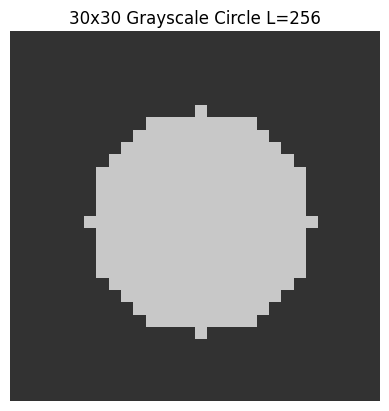

In [100]:
# criar uma imagem contendo um círculo em escala de cinza de 30x30 pixels
image_size = 30
image = np.zeros((image_size, image_size), dtype=np.uint8)

# Define the center and radius for the two 'loops' of the infinity symbol
center_y, center_x = image_size // 2, image_size // 2

# o tamanho do desenho ocupará 60% da largura e da altura da imagem, deixando 40% de margem
desenho_altura = int(image_size * 0.6)
desenho_largura = int(image_size * 0.6)

# o formato do desenho será um círculo
raio = desenho_altura // 2

# definindo nível de cinza L
L = 256

# mudar a cor do fundo da imagem para cinza escuro
image[:] = int(L*(50/256)) # Changed background to a darker gray

# Desenhar o circulo
for y in range(image_size):
  for x in range(image_size):
    # calular a distancia entre a coordenada (x, y) atual e verificar se está dentro o raio
    distancia = np.sqrt((x - center_x)**2 + (y - center_y)**2)
    if distancia <= raio:
      image[y, x] = int(L*(200/256)) # Kept circle as light gray

# Convert to PIL Image
pil_image = Image.fromarray(image)

# Display the image
plt.imshow(pil_image, cmap='gray', vmin=0, vmax=255) # Added vmin and vmax for explicit grayscale mapping
plt.title(f'30x30 Grayscale Circle L={L}')
plt.axis('off') # Hide axes
plt.show()

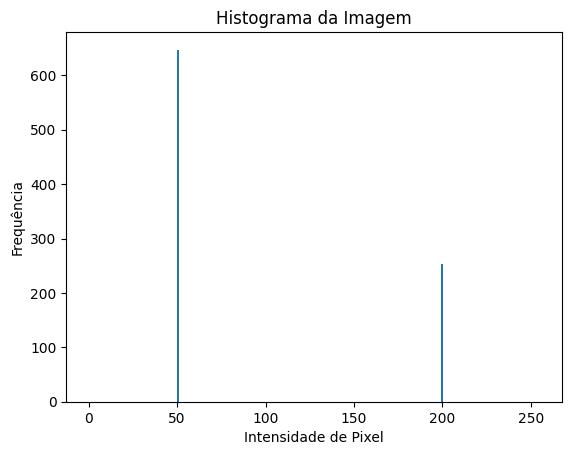

In [101]:
# mostrar o histograma da imagem
plt.hist(image.ravel(), bins=L, range=(0, L-1), fc='k', ec='k')
plt.xlabel('Intensidade de Pixel')
plt.ylabel('Frequência')
plt.title('Histograma da Imagem')
plt.show()

## 2. Cálculo do limiar (k) da imagem

2.1. Criar uma matriz com o histograma da imagem

2.2. Calcular o $p_i$ para cada nível de pixel
$$p_i = \frac{n_i}{N}, \quad p_i \ge 0, \quad \sum_{i=0}^{L-1} p_i = 1$$

2.3. Criar funções para calcular pesos e médias das classes $C_0$ e $C_1$ e média global
- $C_0$ (Fundo): Pixels com níveis de cinza no intervalo $[0, k]$.
- $C_1$ (Objeto): Pixels com níveis de cinza no intervalo $[k+1, L-1]$.
- $\omega_0(k)$: Peso da classe $C_0$
- $\omega_1(k)$: Peso da classe $C_1$
- $\omega_T(k)$: Peso global da imagem
- $\mu_0(k)$: Média da classe $C_0$
- $\mu_1(k)$: Média da classe $C_1$

2.4 Criar função parfa calcular o valor de $k$ para a máxima variância entre as classes ($\sigma_B^2$) usando o método bruto, ou seja, calculando a variância entre as classes para todos os valores possíveis de $k$

$$\sigma_B^2(k) = \omega_0(k)(\mu_0(k) - \mu_T)^2 + \omega_1(k)(\mu_1(k) - \mu_T)^2$$


### 2.1 Criar uma matriz com histograma da imagem

In [102]:
image_hist, bins = np.histogram(image.ravel(), bins=L, range=(0, L-1))
print(f"{'Nível do pixel (i)':<20} | {'Quantidade (ni)':<15}")
print(f"{'-'*20} | {'-'*15}")
for i in range(L):
  if image_hist[i] > 0:
    print(f"{i:<20} | {image_hist[i]:<15}")

Nível do pixel (i)   | Quantidade (ni)
-------------------- | ---------------
50                   | 647            
200                  | 253            


### 2.2 Calcular $p_i$ para cada nível de pixel

In [103]:
pi_img = image_hist / image_hist.sum()
print(f"{'Nível do pixel (i)':<20} | {'p_i':<15}")
print(f"{'-'*20} | {'-'*15}")
for i in range(L):
  if pi_img[i] > 0:
    print(f"{i:<20} | {pi_img[i]:<15}")

Nível do pixel (i)   | p_i            
-------------------- | ---------------
50                   | 0.7188888888888889
200                  | 0.2811111111111111


### 2.3. Criar uma função para calcular pesos e médias das classes $C_0$ e $C_1$
- $C_0$ (Fundo): Pixels com níveis de cinza no intervalo $[0, k]$.
- $C_1$ (Objeto): Pixels com níveis de cinza no intervalo $[k+1, L-1]$.

### Probabilidades (Pesos) das Classes

As probabilidades $\omega_0(k)$ e $\omega_1(k)$ indicam a proporção de pixels que caem em $C_0$ e $C_1$, respectivamente:

$$\omega_0(k) = \sum_{i=0}^{k} p_i$$

$$\omega_1(k) = \sum_{i=k+1}^{L-1} p_i = 1 - \omega_0(k)$$


In [104]:
def calc_peso_classes(k, pi_img):
  omega_0 = pi_img[:k].sum()
  omega_1 = 1 - omega_0
  return omega_0, omega_1

In [105]:
# testando o código
k = 100
omega_0, omega_1 = calc_peso_classes(k, pi_img)
print(f"omega_0(k) = {omega_0}")
print(f"omega_1(k) = {omega_1}")

omega_0(k) = 0.7188888888888889
omega_1(k) = 0.2811111111111111


### Médias das Classes
A média dos níveis de cinza para cada classe, $\mu_0(k)$ e $\mu_1(k)$, são calculadas como:

$$\mu_0(k) = \sum_{i=0}^{k} \frac{i \cdot p_i}{\omega_0(k)}$$

$$\mu_1(k) = \sum_{i=k+1}^{L-1} \frac{i \cdot p_i}{\omega_1(k)}$$


In [106]:
def calc_media_classes(k, pi_img):
  c = 0.00001
  omega_0, omega_1 = calc_peso_classes(k, pi_img)
  mu_0 = (np.arange(k+1) * pi_img[:k+1]).sum() / (omega_0 + c)
  mu_1 = (np.arange(k+1, 256) * pi_img[k+1:]).sum() / (omega_1 + c)
  return mu_0, mu_1

In [107]:
# testando o código
mu_0, mu_1 = calc_media_classes(k, pi_img)
print(f"mu_0(k) = {mu_0}")
print(f"mu_1(k) = {mu_1}")

mu_0(k) = 49.99930449190042
mu_1(k) = 199.99288562857447


### Média Global da Imagem

A média de intensidade de toda a imagem ($\mu_T$) é constante e independente de $k$:

$$\mu_T = \sum_{i=0}^{L-1} i \cdot p_i$$
É fácil demonstrar a seguinte relação fundamental entre as médias:

$$\omega_0(k)\mu_0(k) + \omega_1(k)\mu_1(k) = \mu_T$$


In [108]:
def calc_media_global(pi_img, L=256):
  return (np.arange(L) * pi_img).sum()

In [109]:
# testando o código
mu_T = calc_media_global(pi_img)
print(f"mu_T = {mu_T}")

mu_T = 92.16666666666666


### 2.4 Variância Máxima entre as classes

Criar função parfa calcular o valor de $k$ para a máxima variância entre as classes ($\sigma_B^2$) usando o método bruto, ou seja, calculando a variância entre as classes para todos os valores possíveis de $k$

$$\sigma_B^2(k) = \omega_0(k)(\mu_0(k) - \mu_T)^2 + \omega_1(k)(\mu_1(k) - \mu_T)^2$$

Substituindo a relação da média global ($\mu_T$) na equação acima e simplificando algebricamente, chegamos a uma forma muito mais elegante e computacionalmente vantajosa:

$$\sigma_B^2(k) = \omega_0(k)\omega_1(k) \left[ \mu_0(k) - \mu_1(k) \right]^2$$


In [110]:
def calc_variancia_entre_classes(pi_img, L=256):
  """
  A função deve receber o pi_img e retornar uma matriz das variância entre as classes para cada valor de k.
  """
  mu_T = calc_media_global(pi_img)
  sigma_B2 = np.zeros(L)
  for k in range(L):
    omega_0, omega_1 = calc_peso_classes(k, pi_img)
    mu_0, mu_1 = calc_media_classes(k, pi_img)
    sigma_B2[k] = omega_0 * omega_1 * (mu_0 - mu_1)**2
  return sigma_B2

In [111]:
# testando o código
sigma_B2 = calc_variancia_entre_classes(pi_img)
print("*exibindo somente valores maiores do que zero")
print(f"{'Nível do pixel (i)':<20} | {'sigma_B2':<15}")
print(f"{'-'*20} | {'-'*15}")
for i in range(L):
  if sigma_B2[i] > 0:
    print(f"{i:<20} | {sigma_B2[i]:<15}")

*exibindo somente valores maiores do que zero
Nível do pixel (i)   | sigma_B2       
-------------------- | ---------------
51                   | 4546.583078638713
52                   | 4546.583078638713
53                   | 4546.583078638713
54                   | 4546.583078638713
55                   | 4546.583078638713
56                   | 4546.583078638713
57                   | 4546.583078638713
58                   | 4546.583078638713
59                   | 4546.583078638713
60                   | 4546.583078638713
61                   | 4546.583078638713
62                   | 4546.583078638713
63                   | 4546.583078638713
64                   | 4546.583078638713
65                   | 4546.583078638713
66                   | 4546.583078638713
67                   | 4546.583078638713
68                   | 4546.583078638713
69                   | 4546.583078638713
70                   | 4546.583078638713
71                   | 4546.583078638713
72             

### Quando há vários valores de $k$ para variância máxima entre as classes

A recomendação matemática mais comum (inclusive sugerida no próprio artigo original de Otsu) é calcular a média aritmética de todos os valores de $k$ que atingiram o valor máximo de variância.Se os limiares ótimos formam um conjunto $K^* = \{k_1, k_2, \dots, k_m\}$, o limiar final escolhido será:

$$k^* = \frac{1}{m} \sum_{j=1}^{m} k_j$$

Por que fazer isso? Se você tem um platô de valores máximos idênticos, a média geométrica ou aritmética posiciona o corte exatamente no "centro" desse vale do histograma, garantindo uma binarização estável e bem distribuída entre o fundo e o objeto.


### Calcular a média de $k$

In [112]:
# verificar se há mais de um valor de k para sigma_b2.argmax()
if np.sum(sigma_B2 == sigma_B2.max()) > 1:
  k_max = np.where(sigma_B2 == sigma_B2.max())[0]
  k_medio = np.mean(k_max)
  print("Foi encontrado mais de um valor para k. A média de k será calculada")
  print(f"k médio = {k_medio}")
  print("lista onde k apresenta máxima variância entre as classes")
  print(k_max)
  k = k_medio
else:
  k = sigma_B2.argmax()
  print("Foi encontrado apenas um valor para k. O valor será usado")
  print(f"k = {k}")

Foi encontrado mais de um valor para k. A média de k será calculada
k médio = 125.0
lista onde k apresenta máxima variância entre as classes
[ 51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68
  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86
  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104
 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122
 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140
 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158
 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176
 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194
 195 196 197 198 199]


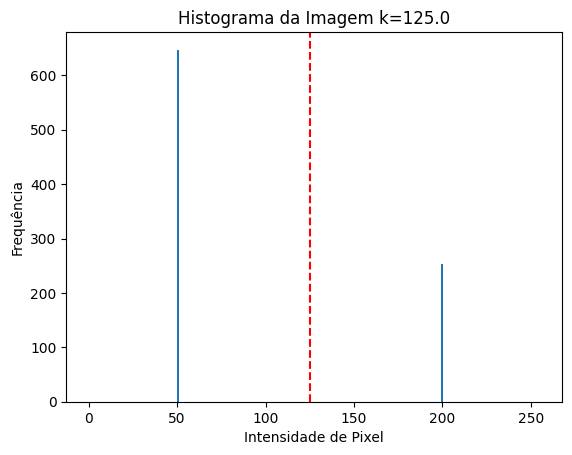

In [113]:
# plotar histograma da imagem e incluir o threshold com uma linha vermelha
plt.hist(image.ravel(), bins=L, range=(0, L-1), fc='k', ec='k')
plt.axvline(x=k, color='r', linestyle='--')
plt.xlabel('Intensidade de Pixel')
plt.ylabel('Frequência')
plt.title(f'Histograma da Imagem k={k}')
plt.show()

In [114]:
# calcular o threshold pela função do skimage
from skimage.filters import threshold_otsu
thresh = threshold_otsu(image)
print(f"Threshold (k) calculado pelo skimage: {thresh}")

Threshold (k) calculado pelo skimage: 50


### Destacar a segmentação da imagem

Vamos destacar a segmentação da imagem tornando os pixels da classe $C_0$ com valor zero e $C_1$ com valor 1

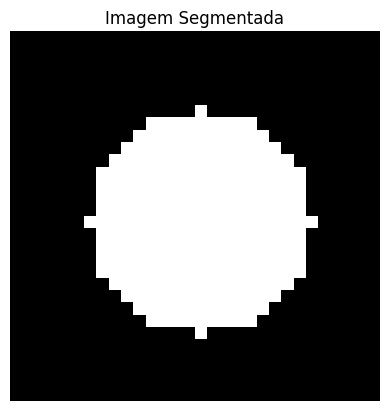

In [115]:
image_segmentada = image.copy()
image_segmentada[image_segmentada < k] = 0
image_segmentada[image_segmentada >= k] = 1

# mostrar imagem segmentada
plt.imshow(image_segmentada, cmap='gray', vmin=0, vmax=1)
plt.title('Imagem Segmentada')
plt.axis('off')
plt.show()

## 3. Adicionar ruído e suavizar a imagem para dificultar os cálculos

(np.float64(-0.5), np.float64(29.5), np.float64(29.5), np.float64(-0.5))

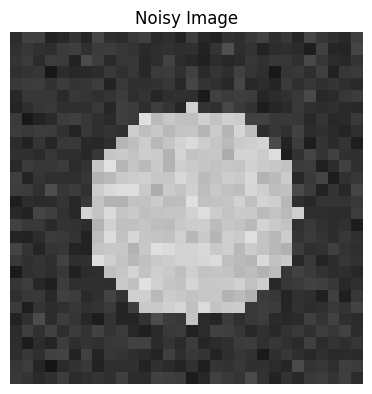

In [116]:
from scipy.ndimage import gaussian_filter

# Create a copy of the original image to add noise to
noisy_image = image.copy().astype(np.float32)

# Add Gaussian noise
# Mean of 0, standard deviation of 20 (adjust as needed)
noise = np.random.normal(loc=0, scale=10, size=noisy_image.shape)
noisy_image = noisy_image + noise

# Clip values to ensure they stay within the valid grayscale range [0, 255]
noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)

# Display the noisy image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(noisy_image, cmap='gray', vmin=0, vmax=255)
plt.title('Noisy Image')
plt.axis('off')

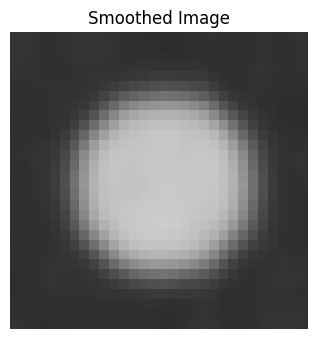

In [117]:
# Smooth the edges using a Gaussian filter
# The 'sigma' parameter controls the amount of smoothing
smoothed_image = gaussian_filter(noisy_image, sigma=1.5) # Adjust sigma for more/less smoothing
smoothed_image = smoothed_image.astype(np.uint8)

# Display the smoothed image
plt.subplot(1, 2, 2)
plt.imshow(smoothed_image, cmap='gray', vmin=0, vmax=255)
plt.title('Smoothed Image')
plt.axis('off')

plt.tight_layout()
plt.show()

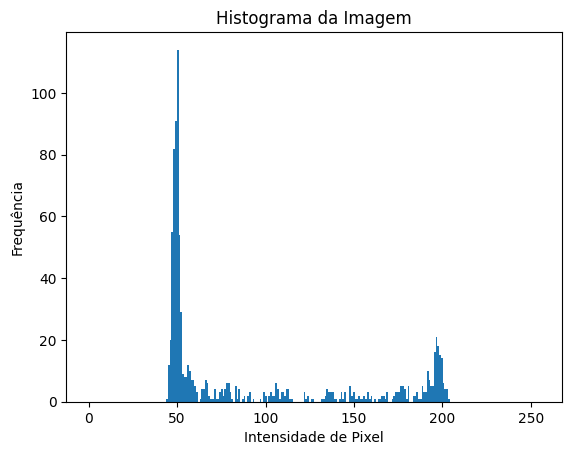

In [118]:
# histograma da nova imagem
plt.hist(smoothed_image.ravel(), bins=256, range=(0, 255), fc='k', ec='k')
plt.xlabel('Intensidade de Pixel')
plt.ylabel('Frequência')
plt.title('Histograma da Imagem')
plt.show()

In [119]:
# criar matriz contendo o histograma da imagem
smoothed_image_hist, bins = np.histogram(smoothed_image.ravel(), bins=256, range=(0, 255))
print(f"{'Nível do pixel (i)':<20} | {'Quantidade (ni)':<15}")
print(f"{'-'*20} | {'-'*15}")
for i in range(256):
  if smoothed_image_hist[i] > 0:
    print(f"{i:<20} | {smoothed_image_hist[i]:<15}")

Nível do pixel (i)   | Quantidade (ni)
-------------------- | ---------------
44                   | 1              
45                   | 12             
46                   | 20             
47                   | 55             
48                   | 82             
49                   | 91             
50                   | 114            
51                   | 54             
52                   | 29             
53                   | 9              
54                   | 8              
55                   | 8              
56                   | 12             
57                   | 10             
58                   | 7              
59                   | 7              
60                   | 5              
61                   | 3              
63                   | 1              
64                   | 4              
65                   | 4              
66                   | 7              
67                   | 6              
68                   | 2 

In [120]:
# calcular pi para cada nível do histograma
pi_seg_img = smoothed_image_hist / smoothed_image_hist.sum()
print(f"{'Nível do pixel (i)':<20} | {'p_i':<15}")
print(f"{'-'*20} | {'-'*15}")
for i in range(256):
  if pi_seg_img[i] > 0:
    print(f"{i:<20} | {pi_seg_img[i]:<15.5f}")

Nível do pixel (i)   | p_i            
-------------------- | ---------------
44                   | 0.00111        
45                   | 0.01333        
46                   | 0.02222        
47                   | 0.06111        
48                   | 0.09111        
49                   | 0.10111        
50                   | 0.12667        
51                   | 0.06000        
52                   | 0.03222        
53                   | 0.01000        
54                   | 0.00889        
55                   | 0.00889        
56                   | 0.01333        
57                   | 0.01111        
58                   | 0.00778        
59                   | 0.00778        
60                   | 0.00556        
61                   | 0.00333        
63                   | 0.00111        
64                   | 0.00444        
65                   | 0.00444        
66                   | 0.00778        
67                   | 0.00667        
68                   | 0.

In [121]:
# calcular matriz de variância entre as classes
sigma_B2 = calc_variancia_entre_classes(pi_seg_img)
print(sigma_B2)

[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 2.64841862e+02 8.98820309e+00 4.15187915e+01
 1.22114609e-02 7.06428611e+01 1.83231560e+02 8.75747980e+02
 1.35201380e+03 1.72480828e+03 1.79873255e+03 1.85631881e+03
 1.87114089e+03 1.98196740e+03 2.09359077e+03 2.14833762e+03
 2.22906245e+03 2.29532928e+03 2.35996492e+03 2.34617954e+03
 2.31205638e+03 2.342176

In [122]:
# verificar quantos valores de k apresentam variação máxima
print(f"Variância Máxima entre Classes: {sigma_B2.max()}")
print(f"Quantidade de k com variância máxima: {np.sum(sigma_B2 == sigma_B2.max())}")
if np.sum(sigma_B2 == sigma_B2.max()) > 1:
  k_max = np.where(sigma_B2 == sigma_B2.max())[0]
  print("A média de k será calculada")
  k_medio = np.mean(k_max)
  print(f"k médio = {k_medio}")
else:
  k = sigma_B2.argmax()
  print(f"k = {k}")


Variância Máxima entre Classes: 3001.6819670498166
Quantidade de k com variância máxima: 2
A média de k será calculada
k médio = 120.5


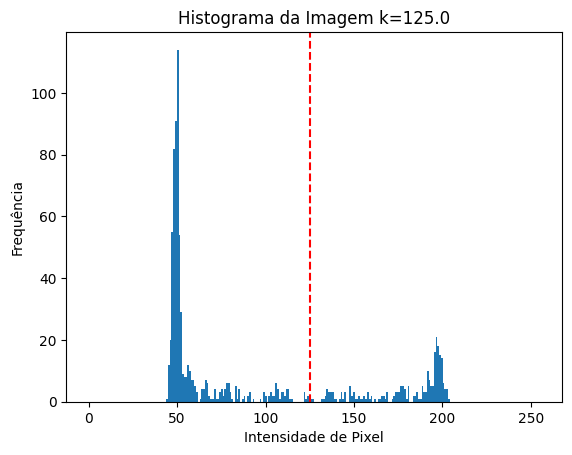

In [123]:
# plotar hist com k
plt.hist(smoothed_image.ravel(), bins=256, range=(0, 255), fc='k', ec='k')
plt.axvline(x=k, color='r', linestyle='--')
plt.xlabel('Intensidade de Pixel')
plt.ylabel('Frequência')
plt.title(f'Histograma da Imagem k={k}')
plt.show()

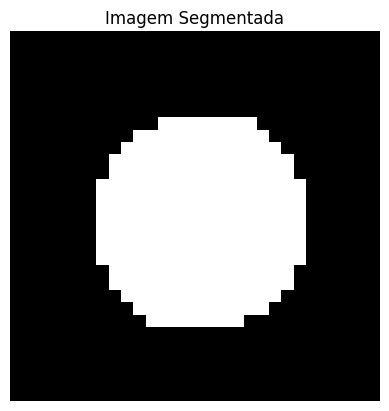

In [124]:
# destacar a imagem segmentada
smoothed_image_segmentada = smoothed_image.copy()
smoothed_image_segmentada[smoothed_image_segmentada < k] = 0
smoothed_image_segmentada[smoothed_image_segmentada >= k] = 1

plt.imshow(smoothed_image_segmentada, cmap='gray', vmin=0, vmax=1)
plt.title('Imagem Segmentada')
plt.axis('off')
plt.show()

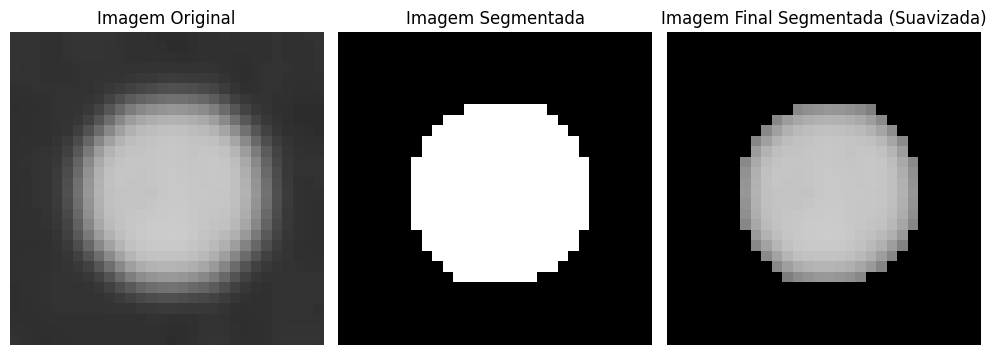

In [135]:
# mosrtrar as imagens smoothed e segmentada
fig, axs = plt.subplots(1, 3, figsize=(10, 5))

axs[0].imshow(smoothed_image, cmap='gray', vmin=0, vmax=255)
axs[0].set_title('Imagem Original')
axs[0].axis('off')

axs[1].imshow(smoothed_image_segmentada, cmap='gray', vmin=0, vmax=1)
axs[1].set_title('Imagem Segmentada')
axs[1].axis('off')

# A imagem final é a imagem suavizada após a segmentação.
img_final = smoothed_image_segmentada * smoothed_image
axs[2].imshow(img_final, cmap='gray', vmin=0, vmax=255)
axs[2].set_title('Imagem Final Segmentada (Suavizada)')
axs[2].axis('off')


plt.tight_layout()
plt.show()

## Testar com uma foto real da Lua

Fazer upload do arquivo lua.jpg

Shape of the grayscale image: (635, 1024)
Data type of the grayscale image: uint8


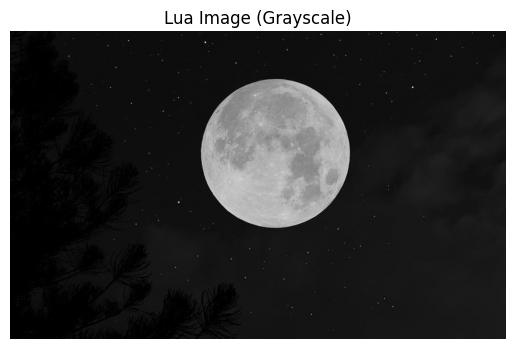

In [127]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = '/content/lua.jpg'
moon_image_pil = Image.open(image_path)

# Convert to grayscale (padrão usa colors: int(256))
moon_image_gray_pil = moon_image_pil.convert('L')

# Convert to NumPy array
lua_img = np.array(moon_image_gray_pil)

print(f"Shape of the grayscale image: {lua_img.shape}")
print(f"Data type of the grayscale image: {lua_img.dtype}")

# Display the grayscale image
plt.imshow(lua_img, cmap='gray')
plt.title('Lua Image (Grayscale)')
plt.axis('off')
plt.show()

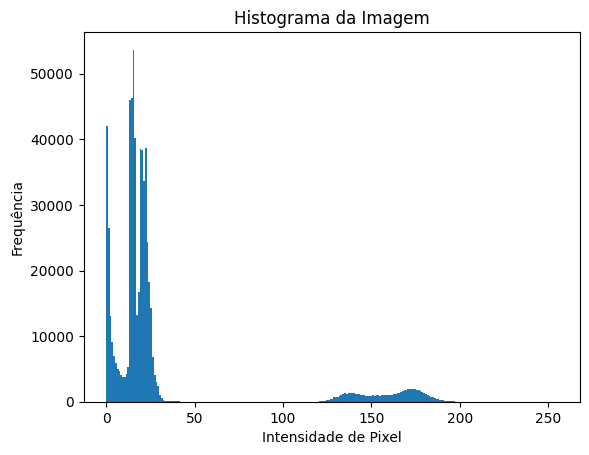

In [128]:
# vamos ver o histograma e salva-lo
plt.hist(lua_img.ravel(), bins=256, range=(0, 255), fc='k', ec='k')
plt.xlabel('Intensidade de Pixel')
plt.ylabel('Frequência')
plt.title('Histograma da Imagem')
plt.show()

In [129]:
# calcular pi da imagem
lua_hist = np.histogram(lua_img.ravel(), bins=256, range=(0, 255))
pi_lua = lua_hist[0] / lua_hist[0].sum()

In [130]:
# calcular variancias
sigma_B2_lua = calc_variancia_entre_classes(pi_lua)

# verificar quantidade de valores máximos
print(f"Variância Máxima entre Classes: {sigma_B2_lua.max()}")
print(f"Quantidade de k com variância máxima: {np.sum(sigma_B2_lua == sigma_B2_lua.max())}")

# encontrar valor de k
if np.sum(sigma_B2_lua == sigma_B2_lua.max()) > 1:
  k_max = np.where(sigma_B2_lua == sigma_B2_lua.max())[0]
  print("Como há mais de um valor para k a média de k será calculada")
  k_medio = np.mean(k_max)
  print(f"k médio = {k_medio}")
  k = k_medio
else:
  k = sigma_B2_lua.argmax()
  print(f"k = {k}")

Variância Máxima entre Classes: 2103.2507217157818
Quantidade de k com variância máxima: 1
k = 89


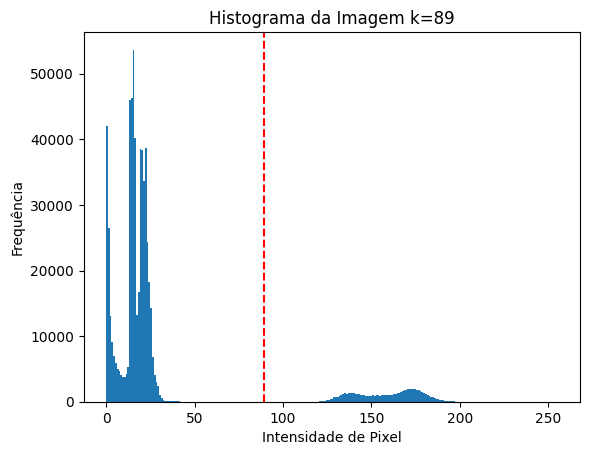

In [131]:
# plotar o histograma com a linha de threshold em vermelho
plt.hist(lua_img.ravel(), bins=256, range=(0, 255), fc='k', ec='k')
plt.axvline(x=k, color='r', linestyle='--')
plt.xlabel('Intensidade de Pixel')
plt.ylabel('Frequência')
plt.title(f'Histograma da Imagem k={k}')
plt.show()

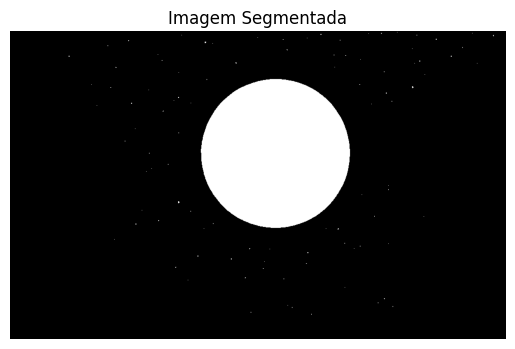

In [132]:
# criar imagem de segmentação
filtro_lua = lua_img.copy()
filtro_lua[filtro_lua < k] = 0
filtro_lua[filtro_lua >= k] = 1

# plotar imagem
plt.imshow(filtro_lua, cmap='gray', vmin=0, vmax=1)
plt.title('Imagem Segmentada')
plt.axis('off')
plt.show()

O algorítmo funcionou como esperado, separando as partes com diferentes luminosidades, mantendo visíveis a lua e as estrelas, áreas mais iluminadas da imagem.

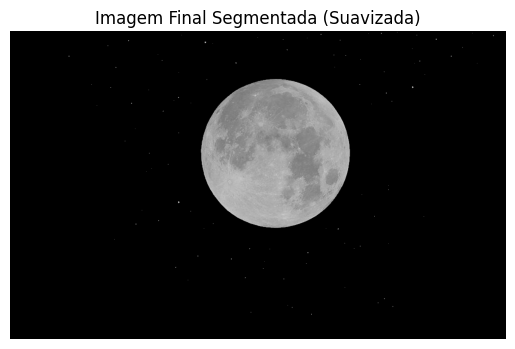

In [133]:
lua_segmentada = lua_img * filtro_lua

plt.imshow(lua_segmentada, cmap='gray', vmin=0, vmax=255)
plt.title('Imagem Final Segmentada (Suavizada)')
plt.axis('off')
plt.show()

## Usar a função threshold_otsu do scikit-image

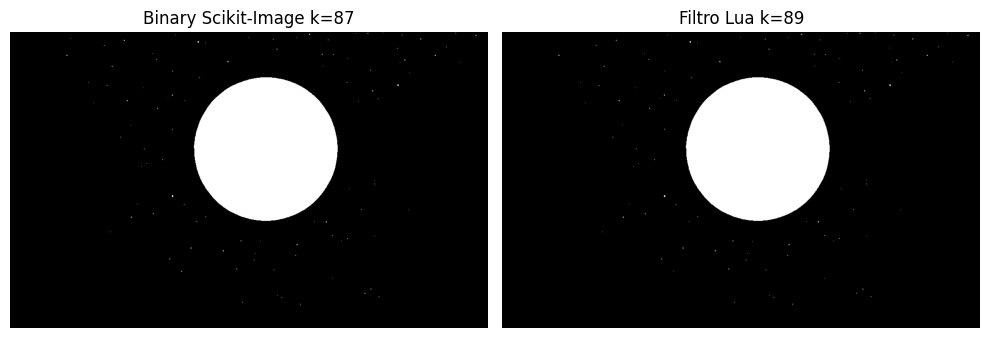

In [134]:
from skimage.filters import threshold_otsu

thresh = threshold_otsu(lua_img)
binary_img = lua_img > thresh

# mosrtrar as imagens geradas por mim e pla função scikit-image
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(binary_img, cmap='gray', vmin=0, vmax=1)
axs[0].set_title(f'Binary Scikit-Image k={thresh}')
axs[0].axis('off')

axs[1].imshow(filtro_lua, cmap='gray', vmin=0, vmax=1)
axs[1].set_title(f'Filtro Lua k={k}')
axs[1].axis('off')

plt.tight_layout()
plt.show()